<h1><strong>Univariate Imputation</strong></h1>
<h3><strong>Categorical Feature Imputation</strong></h3>

In [17]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'City':['Delhi','Mumbai','Noida','Noida','Mumbai',np.nan,'Noida','Noida',np.nan,'Delhi'],
    'Membership':['Gold','Silver',np.nan,'Silver','Gold','Silver',np.nan,np.nan,'Silver','Silver']
}

df = pd.DataFrame(data)

In [18]:
df

,City,Membership
0,Delhi,Gold
1,Mumbai,Silver
2,Noida,NaN
3,Noida,Silver
4,Mumbai,Gold
5,NaN,Silver
6,Noida,NaN
7,Noida,NaN
8,NaN,Silver
9,Delhi,Silver


<h3><strong>Mode Imputation(Most Frequent Category)</strong></h3>

The mode is the category that appears most often. In mode imputation, we replace every NaN with dominant class.

In [19]:
from sklearn.impute import SimpleImputer

imputer_mode = SimpleImputer(strategy='most_frequent')

df['City_Mode'] = imputer_mode.fit_transform(df[['City']]).ravel()

In [20]:
df['Membership_mode'] = imputer_mode.fit_transform(df[['Membership']]).ravel()

In [12]:
df['City'] = imputer_mode.fit_transform(df[['City']]).ravel()

In [21]:
df

,City,Membership,City_Mode,Membership_mode
0,Delhi,Gold,Delhi,Gold
1,Mumbai,Silver,Mumbai,Silver
2,Noida,NaN,Noida,Silver
3,Noida,Silver,Noida,Silver
4,Mumbai,Gold,Mumbai,Gold
5,NaN,Silver,Noida,Silver
6,Noida,NaN,Noida,Silver
7,Noida,NaN,Noida,Silver
8,NaN,Silver,Noida,Silver
9,Delhi,Silver,Delhi,Silver


<h3><strong>When to use / When not to use</strong></h3>

<strong>Use:</strong>When missingness is low than 5% and the dataset is MCAR.

<strong>Avoid:</strong> When the dataset is highly impbalanced If one class is 90% of your data, addding more to it via imputation makes the other 10% almost invisible to the model.

<h2><strong>Constant Value Imputation</strong></h2>

Instead guessing, and existing category, we create a brand new one. We replace NaN with string like "Missing","Unknown", or "other".

In [22]:
df['Membership_Constant'] = df['Membership'].fillna('Missing') 

In [23]:
df

,City,Membership,City_Mode,Membership_mode,Membership_Constant
0,Delhi,Gold,Delhi,Gold,Gold
1,Mumbai,Silver,Mumbai,Silver,Silver
2,Noida,NaN,Noida,Silver,Missing
3,Noida,Silver,Noida,Silver,Silver
4,Mumbai,Gold,Mumbai,Gold,Gold
5,NaN,Silver,Noida,Silver,Silver
6,Noida,NaN,Noida,Silver,Missing
7,Noida,NaN,Noida,Silver,Missing
8,NaN,Silver,Noida,Silver,Silver
9,Delhi,Silver,Delhi,Silver,Silver


<h3><strong>When to use/ When to not</strong></h3>
<strong>Use:</strong> When missing is high greater than 10% or when you suspect the data is MNAR(Missng for a reason).<br>
<strong>Avoid:</strong> When the number of unique categories is already very high , as adding one more does not help.

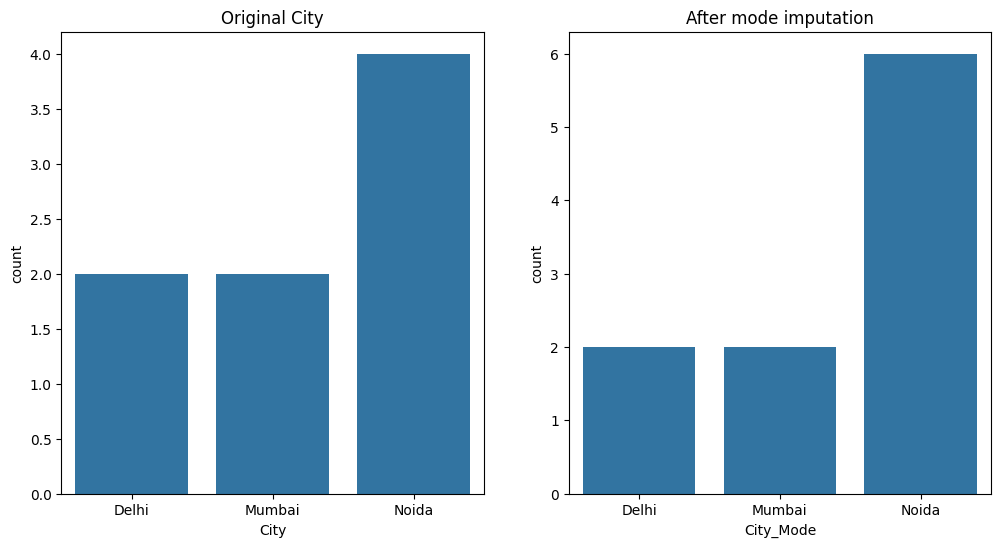

In [24]:
import seaborn as sns

fig, axes = plt.subplots(1,2,figsize=(12,6))

sns.countplot(x='City',data=df,ax=axes[0]).set_title("Original City")
sns.countplot(x='City_Mode',data=df,ax=axes[1]).set_title("After mode imputation")

plt.show()

<h1><strong>Multivariate Imputation</strong></h1>

Multivariate imputation uses the relationships between all available features to estimate a missing value. It views a missing cell not as a hole to be filled by an average, but as a variable to be predicted based on other clues in the rows.

<h3><strong>KNN(K-nearest neighbors)</strong></h3>



In [26]:
import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

data = {
    'Experience':[1,2,3,10,11,12,20,21,np.nan],
    'Salary':[45000,50000,np.nan,110000,120000,125000,200000,np.nan,210000],
    'Age':[22,24,23,35,np.nan,38,50,52,51]
}

df = pd.DataFrame(data)
df

,Experience,Salary,Age
0,1.0,45000.0,22.0
1,2.0,50000.0,24.0
2,3.0,NaN,23.0
3,10.0,110000.0,35.0
4,11.0,120000.0,NaN
5,12.0,125000.0,38.0
6,20.0,200000.0,50.0
7,21.0,NaN,52.0
8,NaN,210000.0,51.0


In [27]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled,columns=df.columns)
df_scaled

,Experience,Salary,Age
0,-1.242118,-1.300386,-1.222266
1,-1.104105,-1.216875,-1.057928
2,-0.966092,NaN,-1.140097
3,0.000000,-0.214743,-0.154067
4,0.138013,-0.047721,NaN
5,0.276026,0.035790,0.092440
6,1.380131,1.288456,1.078470
7,1.518144,NaN,1.242808
8,NaN,1.455478,1.160639


In [35]:
imputer = KNNImputer(n_neighbors=3)

df_imputed_array = imputer.fit_transform(df_scaled)

df_final = pd.DataFrame(scaler.inverse_transform(df_imputed_array),columns=df.columns)
df_final

,Experience,Salary,Age
0,1.000000,45000.000000,22.0
1,2.000000,50000.000000,24.0
2,3.000000,68333.333333,23.0
3,10.000000,110000.000000,35.0
4,11.000000,120000.000000,32.0
5,12.000000,125000.000000,38.0
6,20.000000,200000.000000,50.0
7,21.000000,178333.333333,52.0
8,17.666667,210000.000000,51.0
